# 03 - The Transformer Block, and Why This Won

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

tokens = ["the", "robot", "climbed", "because", "it", "was", "fast"]
embeddings = np.array([
    [0.3, 0.0, 0.0, 0.0],
    [3.0, 0.3, 0.0, 1.5],
    [0.0, 0.0, 3.0, 0.4],
    [0.0, 0.3, 0.0, 0.0],
    [2.8, 0.2, 0.0, 0.0],
    [0.0, 0.0, 0.3, 0.0],
    [0.0, 0.0, 2.8, 0.3],
])

def softmax_rows(z):
    z = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

## One Head Isn't Enough

`02-attention-mechanism.ipynb` found two separate relationships in the same sentence - `it -> robot` (coreference) and `fast -> climbed` (manner of action) - but only by looking at the *same* attention weights for both. A real sentence needs to track many kinds of relationships simultaneously, and a single attention computation has to compress all of them into one set of weights per token pair. **Multi-Head Attention** runs several attention computations in parallel - each with its own Q/K/V projection - so different heads can specialize in different relationships, then concatenates all the heads' outputs back together.

In [2]:
def attention_head(x, projection_matrix):
    """One attention head: project x with `projection_matrix`, then self-attend."""
    projected = x @ projection_matrix
    d_k = projected.shape[1]
    scores = (projected @ projected.T) / np.sqrt(d_k)
    weights = softmax_rows(scores)
    return weights, weights @ projected

def selector_matrix(dims, total_dim=4):
    """A projection matrix that just picks out specific dimensions - a simple, fully
    transparent stand-in for a learned projection, so each head's specialization is
    something we designed rather than something we'd have to train to see."""
    matrix = np.zeros((total_dim, len(dims)))
    for i, dim in enumerate(dims):
        matrix[dim, i] = 1.0
    return matrix

# Head A only ever looks at dims [0, 1] - exactly the dimensions carrying the
# 'it'/'robot' signal from notebook 02. Head B only looks at dims [2, 3] - the
# 'climbed'/'fast' signal.
head_a_weights, head_a_output = attention_head(embeddings, selector_matrix([0, 1]))
head_b_weights, head_b_output = attention_head(embeddings, selector_matrix([2, 3]))

it_idx, fast_idx = tokens.index("it"), tokens.index("fast")
print(f"Head A - 'it' attends most to: '{tokens[np.argmax(head_a_weights[it_idx])]}'")
print(f"Head B - 'fast' attends most to: '{tokens[np.argmax(head_b_weights[fast_idx])]}'")

multi_head_output = np.concatenate([head_a_output, head_b_output], axis=1)
print(f"\nConcatenated multi-head output shape: {multi_head_output.shape}")

Head A - 'it' attends most to: 'robot'
Head B - 'fast' attends most to: 'climbed'

Concatenated multi-head output shape: (7, 4)


Each head recovered a *different* relationship, purely because it was only looking at a different slice of the representation. Real Transformers don't hand-pick which dimensions each head sees the way this notebook just did - they learn their own projection matrices through training, and different heads reliably end up specializing in different kinds of relationships (some heads track nearby words, some track long-range dependencies, some track syntax) without ever being told to.

## Residual Connections and Layer Normalization

Two more pieces wrap around both attention and the feedforward step you'll see next:

- A **Residual Connection** adds a sub-layer's *input* back onto its *output* ($x + \text{sublayer}(x)$, not just $\text{sublayer}(x)$ alone). This makes very deep stacks of blocks far easier to train - if a particular block has nothing useful to contribute yet, the default behavior is to pass its input through essentially unchanged, rather than needing to learn an exact identity mapping from scratch just to avoid destroying information.
- **Layer Normalization** rescales each token's vector to have consistent mean (0) and spread (variance 1) before it moves to the next step - similar in spirit to the `StandardScaler` from `ml_primer/03-train-tune-eval.ipynb`, just applied fresh to every token at every layer instead of once to a whole dataset up front, keeping values in a consistent, well-behaved range no matter how deep the stack gets.

In [3]:
def layer_norm(x, eps=1e-6):
    mean = x.mean(axis=1, keepdims=True)
    variance = x.var(axis=1, keepdims=True)
    return (x - mean) / np.sqrt(variance + eps)

normalized = layer_norm(embeddings)
print("Per-row mean after layer norm (should be ~0):", normalized.mean(axis=1).round(4))
print("Per-row std after layer norm (should be ~1):", normalized.std(axis=1).round(4))

Per-row mean after layer norm (should be ~0): [ 0.  0. -0.  0. -0.  0.  0.]
Per-row std after layer norm (should be ~1): [1. 1. 1. 1. 1. 1. 1.]


## Assembling One Transformer Block

A **Transformer Block** is: multi-head attention, wrapped in a residual connection and layer norm, followed by a feedforward network (an ordinary 2-layer network, exactly `deep_learning_primer/01`'s shape, applied independently to *each* token's vector - no cross-token mixing here, that already happened in the attention step), also wrapped in its own residual connection and layer norm.

In [4]:
d_model = embeddings.shape[1]
hidden_dim = 8

W1_ff = np.random.randn(d_model, hidden_dim) * 0.3
b1_ff = np.zeros(hidden_dim)
W2_ff = np.random.randn(hidden_dim, d_model) * 0.3
b2_ff = np.zeros(d_model)

def relu(z):
    return np.maximum(0, z)

def feedforward(x):
    return relu(x @ W1_ff + b1_ff) @ W2_ff + b2_ff

def self_attention(x):
    d_k = x.shape[1]
    scores = (x @ x.T) / np.sqrt(d_k)
    weights = softmax_rows(scores)
    return weights @ x

def transformer_block(x):
    attention_out = self_attention(x)
    x = layer_norm(x + attention_out)   # residual + layer norm, around attention
    feedforward_out = feedforward(x)
    x = layer_norm(x + feedforward_out)  # residual + layer norm, around the feedforward
    return x

block_output = transformer_block(embeddings)
print(f"Input shape:  {embeddings.shape}")
print(f"Output shape: {block_output.shape}")
print(f"Any NaN in output: {np.isnan(block_output).any()}")

Input shape:  (7, 4)
Output shape: (7, 4)
Any NaN in output: False


The output shape *exactly matches* the input shape - one vector per token in, one vector per token out. That's what lets Transformer Blocks **stack**: the output of one block is a perfectly valid input to the next, so a real model just repeats this same block, unchanged in shape, dozens of times (GPT-3 stacks 96 of them) to build up increasingly refined representations.

## The Causal Mask

One more piece matters specifically for a model that *generates* text one token at a time: it can't be allowed to attend to tokens that come after the one it's currently generating - that would be looking at its own future output before producing it. A **Causal Mask** enforces this by setting every "attend to a later position" score to $-\infty$ before the softmax, so it becomes exactly 0 after.

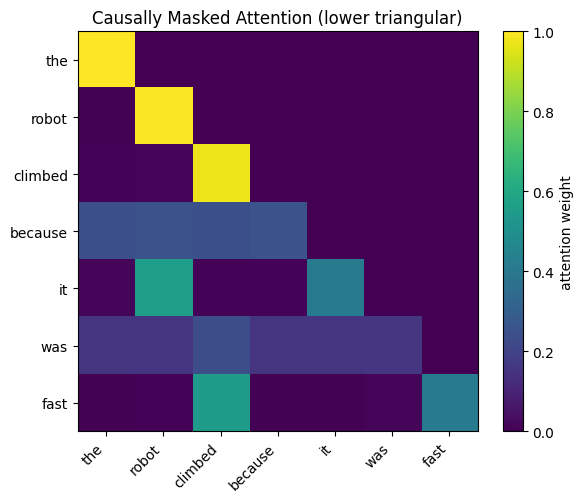

'it' can still see 'robot' (comes before it): 0.556
'it' attending to 'fast' (comes after it):    0.000


In [5]:
sequence_length = len(tokens)
causal_mask = np.triu(np.ones((sequence_length, sequence_length)), k=1).astype(bool)

raw_scores = (embeddings @ embeddings.T) / np.sqrt(d_model)
masked_scores = np.where(causal_mask, -np.inf, raw_scores)
causal_weights = softmax_rows(masked_scores)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(causal_weights, cmap='viridis')
ax.set_xticks(range(len(tokens))); ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)
ax.set_title('Causally Masked Attention (lower triangular)')
plt.colorbar(im, label='attention weight')
plt.tight_layout()
plt.show()

print(f"'it' can still see 'robot' (comes before it): {causal_weights[tokens.index('it'), tokens.index('robot')]:.3f}")
print(f"'it' attending to 'fast' (comes after it):    {causal_weights[tokens.index('it'), tokens.index('fast')]:.3f}")

The heatmap should look strictly lower-triangular - every cell above the diagonal is exactly 0. `it` still finds `robot` (which comes *before* it in the sentence), but gets nothing at all from `fast` or `was`, which come after. A model built this way - **GPT-style, decoder-only** - is built specifically for generation, one token at a time, in order. A model *without* the causal mask - **BERT-style, encoder-only** - can see the whole sequence at once in both directions, which is useless for generating new text but better suited to understanding an already-complete piece of text (classifying it, extracting information from it). Same Transformer Block either way - only the masking differs.

## Why This Won

Before Transformers, sequence models (RNNs, LSTMs) processed a sequence one token at a time *in order*, carrying everything they'd seen so far in a single running hidden state. This had two real costs: training couldn't parallelize across the sequence (token 50 had to wait for token 49 to finish), and information from far back in a long sequence had to survive being compressed through dozens or hundreds of sequential updates to that one hidden state - exactly the kind of long chain that lets small errors and lost information compound, similar in spirit to the drift problem from `back_end_resources/systems_primer/04b_motion_control_and_trajectories`, just for information instead of position.

*Attention Is All You Need* (Vaswani et al., 2017) replaced that sequential hidden state with exactly the mechanism you just built: every token attends *directly* to every other token in one step, regardless of how far apart they are. That fixes both problems at once - the whole sequence can be processed in parallel, and there's no long chain of sequential updates for a distant token's information to decay through.

That raises an honest question, though: if attention can look anywhere with equal ease, why does `agent_primer/02-tokens-and-context.md`'s **Lost in the Middle Effect** still happen? A few real, documented reasons, not a flaw in the mechanism itself:

- **Training data is skewed toward the beginning and end mattering more** - real documents put titles and introductions first and conclusions last far more often than they bury the single most important fact in the exact middle, so a model trained on real text learns attention patterns that reflect that same bias.
- **Longer contexts mean more competition for a fixed amount of attention.** Softmax always distributes exactly 1.0 of total weight across every candidate - the more tokens competing for it, the smaller the average slice anything gets, so a genuinely relevant token buried among thousands of others gets diluted even though nothing architecturally forbids attending to it.
- **Real positional encoding schemes** (like RoPE, used in many current models) have their own documented biases favoring nearby positions over distant ones, layered on top of the attention mechanism itself.

None of these are bugs, exactly - they're properties of how these models are actually trained and positioned, not evidence that attention secretly can't look at the middle of a long context. But they're also exactly why `agent_primer/03-context-engineering.md`'s advice to put decision-relevant content near the start or end of a prompt is good practical advice, not superstition.

## Try It Yourself

Build four single-dimension heads, one for each of `selector_matrix([0])`, `[1]`, `[2]`, and `[3]`, and compare their peak attention weight (`weights.max(axis=1)`) against each other and against Head A (dims `[0,1]`) and Head B (dims `[2,3]`) from above.

Before you run it, guess: will combining two dimensions into one head always produce a *more* decisive attention pattern than either dimension alone, since it has more information to work with? Run all four single-dimension heads and check. Write one sentence on what you actually find, and what it tells you about whether "more dimensions in a head" and "more decisive attention" are the same thing.

In [6]:
# TODO: build single-dimension heads for dims [0], [1], [2], and [3] using
# selector_matrix, print each one's peak attention weight (weights.max(axis=1)),
# and compare against head_a_weights and head_b_weights's peaks from above


## Resources

- Vaswani, A. et al. (2017). "Attention Is All You Need." *NeurIPS 2017*. Section 3 covers Multi-Head Attention and the full Transformer Block architecture built above (paper).
- Liu, N. F. et al. (2023). "Lost in the Middle: How Language Models Use Long Contexts." Already linked from `ai_primer/01-context-is-key.md`; revisit now with the real mechanism behind it (paper).
- [Jay Alammar: The Illustrated GPT-2](https://jalammar.github.io/illustrated-gpt2/) - a clear walkthrough of the decoder-only, causally-masked architecture built in this notebook's second half (instructional).